# Bias Analysis
###### Data Scientist: Maddalena Manfredi - 71946

This section performs a bias audit of the NovaCred credit-decision dataset to assess whether approval outcomes differ systematically across demographic groups. The goal is to identify potential patterns of discrimination and evaluate whether certain groups experience disproportionately lower approval rates.

To detect such disparities, the analysis applies commonly used algorithmic fairness metrics and statistical checks. A key metric used throughout the analysis is the Disparate Impact (DI) ratio, which compares the approval rate of an unprivileged group to that of a privileged group.
$$
DI = \frac{\text{approval rate (unprivileged group)}}{\text{approval rate (privileged group)}}
$$

A value of **_DI<0.8_** indicates potential disparate impact and therefore warrants further investigation

dopo aver individuato possibili disparità, andremo a testare tramite chi-square statistic test, se effettivamente c'è evidenza di una disparità o meno. poi per le varie variabili cerceremo di fare una interaction effect analysis e una proxy.

### Steps:
1. Loading 
2. Bias analysis - DI (gender/age/salary???/geographic??) . In questa sezione ho analizzato le variabili gender e age per vedere se ci fossero dei bias per queste variabili, ogni volto ho controllato e pulito il dataset, ho fatto il DI ratio e per controllare che ci fosse una significatività statistica ho fato il Chi-square test of independence.
3. Interaction effect
4. Proxy Analysis
5. Conclusions and Reccomandations

In [ ]:
##Libraries
import re, json
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np
from scipy.stats import chi2_contingency
import numpy as np

## 1. Loading of the data

In [ ]:

# Load raw JSON
path = Path("..") / "Data" / "raw_credit_applications.json"
with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

# Flatten nested JSON → tabular
flat = pd.json_normalize(data, sep=".")

(502, 21)

In [5]:
flat.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


## 2. DI Analysis

## Gender Bias

Based on the analyses conducted in the file "01-data-quality", the variable "applicant_info.gender" contains one missing value, which is excluded from the analysis.

The raw "applicant_info.gender" field contained multiple encodings, including Male, Female, M, and F. To ensure consistency, the values M and F were mapped to Male and Female, respectively, and stored in a new variable called "gender".

The dataset contains three missing or invalid values. These observations are retained in the dataset but excluded from the binary fairness comparisons in order to avoid distorting the metrics.

### Data Cleaning

In [7]:
# Gender encoding normalisation: M → Male, F → Female
gender_map = {"M": "Male", "F": "Female"}

flat["gender"] = (
    flat["applicant_info.gender"]
    .str.strip()
    .replace(gender_map)
    .where(lambda s: s.isin(["Male", "Female"]))  # set others (nulls, unknowns) to NaN
)

# Sanity check
print(flat["applicant_info.gender"].value_counts(dropna=False).rename("raw"))
print()
print(flat["gender"].value_counts(dropna=False).rename("clean"))

flat = flat.drop(columns=["applicant_info.gender"])

applicant_info.gender
Male      195
Female    193
F          58
M          53
            2
NaN         1
Name: raw, dtype: int64

gender
Female    251
Male      248
NaN         3
Name: clean, dtype: int64


### Disparate Impact (DI) 

gender
Female    0.505976
Male      0.657258

Absolute difference (Female - Male): -0.1513

Disparate Impact (Female / Male): 0.7698
→ POTENTIAL DISPARATE IMPACT (DI < 0.8)


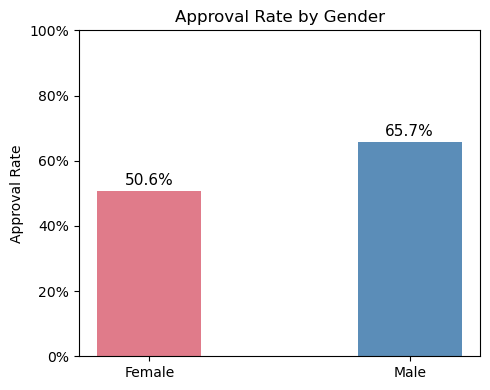

In [37]:
# --- Disparate Impact: Gender ---

# Keep only records with known gender
df_gender = flat[flat["gender"].isin(["Male", "Female"])].copy()

# Approval rates per group
rates = (
    df_gender.groupby("gender")["decision.loan_approved"]
    .mean()
    .rename("approval_rate")
)
print(rates.to_string())

# Absolute difference
diff = abs(rates["Female"] - rates["Male"])
print(f"\nAbsolute difference (Female - Male): {rates['Female'] - rates['Male']:+.4f}")

# DI = approval_rate(Female) / approval_rate(Male)
DI_gender = rates["Female"] / rates["Male"]
print(f"\nDisparate Impact (Female / Male): {DI_gender:.4f}")
print("→", "POTENTIAL DISPARATE IMPACT (DI < 0.8)" if DI_gender < 0.8 else "No disparate impact detected (DI ≥ 0.8)")

fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(rates.index, rates.values, color=["#E07B8A", "#5B8DB8"], width=0.4)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Approval Rate by Gender")
ax.set_ylabel("Approval Rate")
for bar, val in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.1%}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

**Interpretetaion:** The results indicate a disparity in approval rates between the two groups. Female applicants have an approval rate of approximately 0.51, while male applicants have an approval rate of approximately 0.66. The resulting **Disparate Impact (DI) ratio of 0.77** falls below the 0.8 threshold. This suggests the presence of a potential disparate impact against female applicants. 

### Chi-square test of independence: gender vs loan approval

Approved  False  True 
gender                
Female      124    127
Male         85    163

Chi-square statistic : 11.1156
Degrees of freedom   : 1
p-value              : 0.0009
→ Statistically significant disparity (p < 0.05)


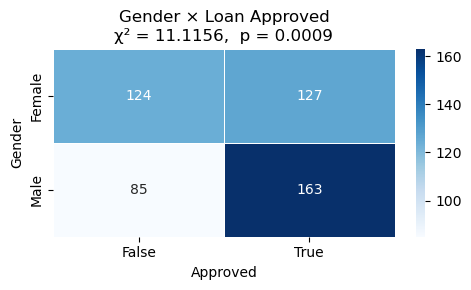

In [19]:
# Contingency table: gender × loan_approved
contingency = pd.crosstab(
    df_gender["gender"],
    df_gender["decision.loan_approved"],
    colnames=["Approved"]
)
print(contingency)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"p-value              : {p_value:.4f}")
print("→", "Statistically significant disparity (p < 0.05)" if p_value < 0.05 else "No statistically significant disparity (p ≥ 0.05)")


fig, ax = plt.subplots(figsize=(5, 3))

sns.heatmap(
    contingency,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax
)
ax.set_title(f"Gender × Loan Approved\nχ² = {chi2:.4f},  p = {p_value:.4f}")
ax.set_xlabel("Approved")
ax.set_ylabel("Gender")

plt.tight_layout()
plt.show()



**Interpretetion:** The test produces a chi-square statistic of 11.12 and a p-value of 0.0009.
Since the p-value is below the significance level of 0.05, the null hypothesis of independence between gender and loan approval can be rejected. This indicates that **loan approval outcomes are statistically associated with gender**, consistent with the disparity suggested by the Disparate Impact metric.

### Interest Rate by Gender (approved only) 
We now investigate whether there is a difference in the interest rates offered to male and female.

          mean  median     std    n
gender                             
Female  4.4882     4.4  1.1929  127
Male    4.6282     4.7  1.1417  163

Mann-Whitney U statistic : 9655.0000
p-value                  : 0.3264
→ No significant difference in interest rates (p ≥ 0.05)


C:\Users\madda\AppData\Local\Temp\ipykernel_1440\905234345.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


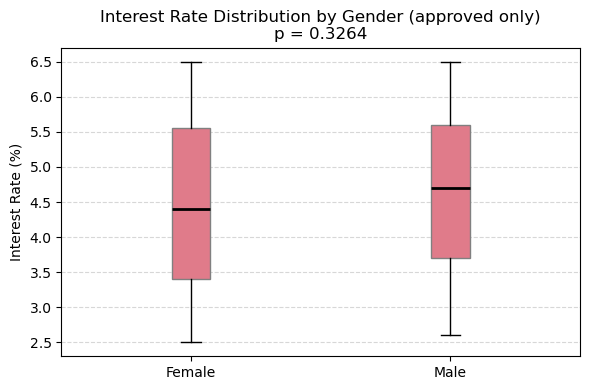

In [36]:
# --- Interest Rate by Gender (approved only) ---

df_approved = df_gender[df_gender["decision.loan_approved"] == True].copy()

ir_stats = (
    df_approved.groupby("gender")["decision.interest_rate"]
    .agg(mean="mean", median="median", std="std", n="count")
)
print(ir_stats.round(4))

# Mann-Whitney U test (non-parametric, no normality assumption)
from scipy.stats import mannwhitneyu

female_ir = df_approved[df_approved["gender"] == "Female"]["decision.interest_rate"].dropna()
male_ir   = df_approved[df_approved["gender"] == "Male"]["decision.interest_rate"].dropna()

stat, p_ir = mannwhitneyu(female_ir, male_ir, alternative="two-sided")
print(f"\nMann-Whitney U statistic : {stat:.4f}")
print(f"p-value                  : {p_ir:.4f}")
print("→", "Significant difference in interest rates (p < 0.05)" if p_ir < 0.05 else "No significant difference in interest rates (p ≥ 0.05)")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(
    [female_ir, male_ir],
    labels=["Female", "Male"],
    patch_artist=True,
    boxprops=dict(facecolor="#E07B8A", color="gray"),
    medianprops=dict(color="black", linewidth=2)
)
ax.set_ylabel("Interest Rate (%)")
ax.set_title(f"Interest Rate Distribution by Gender (approved only)\np = {p_ir:.4f}")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


**Interpretation:** The test produces a p-value of 0.3264, which is greater than the significance level of 0.05. Therefore, the null hypothesis cannot be rejected. This indicates that there is no statistically significant difference in the interest rates offered to male and female applicants among approved loans.

However, descriptively, female applicants appear to have a slightly lower average interest rate. This may be influenced by the presence of a subgroup of female borrowers who received particularly low interest rates (around 2.5%), which lowers the overall mean for women compared to men.

---

## Age Bias 
Based on the analyses conducted in the file "01-data-quality", the variable "applicant_info.date_of_birth" contains one missing value, which is excluded from the analysis.

Several data cleaning steps were also performed to standardize the date-of-birth format. The original data contained different separators (such as - and /) and inconsistent formats (e.g., YY/MM/DD, DD/MM/YY). After standardization, four records remained where the date could not be reliably identified, and these observations are therefore excluded from the age-related analysis.

Finally, a new variable called "age" was created to facilitate subsequent analyses. Age is calculated relative to the reference date 2026-01-01, which serves as the baseline for determining each applicant’s age.

### Data Cleaning

In [42]:
# --- Date of Birth cleaning ---

def parse_dob(val):
    if pd.isna(val):
        return pd.NaT
    val = str(val).strip()
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%m/%d/%Y", "%Y/%m/%d"):
        try:
            return pd.to_datetime(val, format=fmt)
        except ValueError:
            continue
    return pd.NaT

flat["clean_date_of_birth"] = flat["applicant_info.date_of_birth"].apply(parse_dob)

# Report
total     = len(flat)
null_orig = flat["applicant_info.date_of_birth"].isna().sum()
parsed    = flat["clean_date_of_birth"].notna().sum()
failed    = flat["clean_date_of_birth"].isna().sum() - null_orig

print(f"Total records        : {total}")
print(f"Originally null      : {null_orig}")
print(f"Successfully parsed  : {parsed}")
print(f"Still unparseable    : {failed}")
print(f"\nDate range: {flat['clean_date_of_birth'].min().date()} → {flat['clean_date_of_birth'].max().date()}")

reference_date = pd.Timestamp("2026-01-01")
flat["age"] = ((reference_date - flat["clean_date_of_birth"]) / pd.Timedelta(days=365.25)).apply(lambda x: int(x) if pd.notna(x) else pd.NA).astype("Int64")

print(flat[["_id", "clean_date_of_birth", "age"]].head(10))
print(f"\nAge range: {flat['age'].min()} - {flat['age'].max()}")
print(f"Missing age: {flat['age'].isna().sum()}")

Total records        : 502
Originally null      : 1
Successfully parsed  : 497
Still unparseable    : 4

Date range: 1958-09-21 → 2002-04-24
       _id clean_date_of_birth  age
0  app_200          2001-03-09   24
1  app_037          1992-03-31   33
2  app_215          1989-10-24   36
3  app_024          1983-04-25   42
4  app_184          1999-05-21   26
5  app_275          1982-02-14   43
6  app_099          1990-01-28   35
7  app_246          1991-10-11   34
8  app_042          1990-05-04   35
9  app_348          1989-10-10   36

Age range: 23 - 67
Missing age: 5


count    497.0
mean      40.6
std       11.0
min       23.0
25%       32.0
50%       39.0
75%       47.0
max       67.0
Name: age, dtype: Float64

Age group counts:
age_group
18–25     24
26–35    162
36–45    164
46–55     85
56–65     56
65+        6
Name: count, dtype: int64


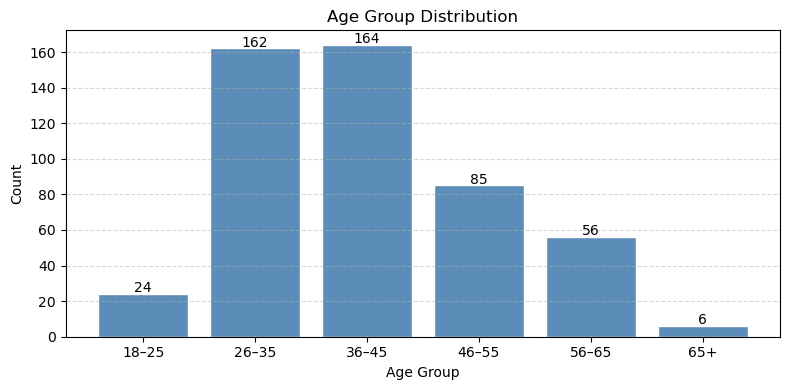

In [ ]:
# --- Age Distribution ---

print(flat["age"].describe().round(1))

# Bin into age groups
bins   = [17, 25, 35, 45, 55, 65, 100]
labels = ["18–25", "26–35", "36–45", "46–55", "56–65", "65+"]
flat["age_group"] = pd.cut(flat["age"].astype("float"), bins=bins, labels=labels)

print("\nAge group counts:")
print(flat["age_group"].value_counts().sort_index())

# Plot
fig, ax = plt.subplots(figsize=(8, 4))

group_counts = flat["age_group"].value_counts().sort_index()
ax.bar(group_counts.index.astype(str), group_counts.values, color="#5B8DB8", edgecolor="white")
ax.set_xlabel("Age Group")
ax.set_ylabel("Count")
ax.set_title("Age Group Distribution")
for i, v in enumerate(group_counts.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Disparate Impact (DI) 

Approval Rate by Age Group:
-----------------------------------
  18–25       45.83%  (n=24)
  26–35       48.15%  (n=162)
  36–45       65.85%  (n=164)
  46–55       63.53%  (n=85)
  56–65       62.50%  (n=56)
  65+         50.00%  (n=6)
-----------------------------------
  Overall     58.15%  (n=497)


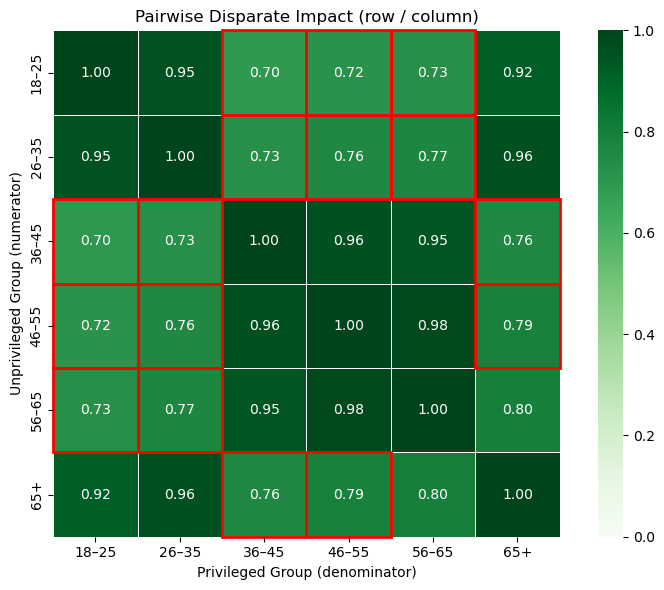

In [50]:
# --- Age Group: Pairwise DI Heatmap ---

# Approval rate per age group
age_rates = (
    flat.dropna(subset=["age_group"])
    .groupby("age_group", observed=True)["decision.loan_approved"]
    .agg(approval_rate="mean", n="count")
)

# Table
overall_n = age_rates["n"].sum()
overall_rate = (age_rates["approval_rate"] * age_rates["n"]).sum() / overall_n

print("Approval Rate by Age Group:")
print("-" * 35)
for idx, row in age_rates.iterrows():
    print(f"  {str(idx):<10}  {row['approval_rate']:.2%}  (n={int(row['n'])})")
print("-" * 35)
print(f"  {'Overall':<10}  {overall_rate:.2%}  (n={overall_n})")



# Pairwise DI matrix: DI[i,j] = approval_rate[i] / approval_rate[j]
groups = age_rates.index.astype(str).tolist()
rates  = age_rates["approval_rate"].values

di_matrix = pd.DataFrame(
    [[min(rates[i], rates[j]) / max(rates[i], rates[j]) if i != j else 1.0
      for j in range(len(rates))]
     for i in range(len(rates))],
    index=groups,
    columns=groups
)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    di_matrix,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True
)

ax.set_title("Pairwise Disparate Impact (row / column)")
ax.set_xlabel("Privileged Group (denominator)")
ax.set_ylabel("Unprivileged Group (numerator)")

# Red border on cells with DI < 0.8 (excluding diagonal)
for i in range(len(groups)):
    for j in range(len(groups)):
        if i != j and di_matrix.iloc[i, j] < 0.8:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="red", lw=2, clip_on=False))

plt.tight_layout()
plt.show()


**Interpretetion:** This heatmap shows the pairwise Disparate Impact (DI) ratios between different age groups.

Looking at the approval statistics, the 18–25 group has the lowest approval rate at 45.83%, very similar to the 26–35 group with an approval rate of 48.15%. In contrast, the middle age groups between 36 and 65 show substantially higher approval rates, ranging from 62.50% to 65.85%. The oldest group (65+) behaves more similarly to the younger groups, with an approval rate of 50%. However, it is important to note that this group contains a very small number of observations (only 6 applicants), which limits the reliability of comparisons involving this category.

As illustrated by the heatmap, the age groups appear to form three distinct clusters. The first cluster includes the younger applicants (18–35), which show very similar approval patterns. The second cluster consists of the middle-age groups (36–65), which share higher approval rates and similar DI ratios among themselves. The third cluster is the 65+ group, which stands apart but shows patterns closer to the younger groups than to the middle-age groups.

Overall, the DI ratios indicate that approval outcomes are not evenly distributed across age groups. The younger applicants (18–35) and the oldest group (65+) show relatively similar approval patterns, while the middle-age groups (36–65) exhibit consistently higher approval rates. This creates a clear contrast between these segments and suggests the presence of potential age-related disparities that warrant further investigation.

### Chi-square test of independence: age vs loan approval

Since the age groups between 18–35 show similar approval rates, and the groups between 36–65 display comparable outcomes among themselves, we aggregate these ranges into broader categories. Therefore, we perform the chi-square test comparing 18–35 vs 36–65, and 36–65 vs 65+ to assess whether approval outcomes differ significantly between these segments.

In [51]:
# Define macro-groups
young   = flat[flat["age_group"].isin(["18–25", "26–35"])]
middle  = flat[flat["age_group"].isin(["36–45", "46–55", "56–65"])]
senior  = flat[flat["age_group"] == "65+"]

def chi2_test(group_a, label_a, group_b, label_b):
    contingency = pd.crosstab(
        pd.concat([group_a.assign(group=label_a), group_b.assign(group=label_b)])["group"],
        pd.concat([group_a, group_b])["decision.loan_approved"],
        colnames=["Approved"]
    )
    print(f"\n--- {label_a} vs {label_b} ---")
    print(contingency)
    chi2, p, dof, _ = chi2_contingency(contingency)
    print(f"Chi-square : {chi2:.4f}")
    print(f"p-value    : {p:.4f}")
    print("→", "Significant disparity (p < 0.05)" if p < 0.05 else "No significant disparity (p ≥ 0.05)")

chi2_test(young,  "18–35", middle, "36–65")
chi2_test(middle, "36–65", senior, "65+")



--- 18–35 vs 36–65 ---
Approved  False  True 
group                 
18–35        97     89
36–65       108    197
Chi-square : 12.6349
p-value    : 0.0004
→ Significant disparity (p < 0.05)

--- 36–65 vs 65+ ---
Approved  False  True 
group                 
36–65       108    197
65+           3      3
Chi-square : 0.0952
p-value    : 0.7577
→ No significant disparity (p ≥ 0.05)


**Interpretetion:** The chi-square test comparing the 18–35 and 36–65 groups produces a p-value of 0.0004. Since this value is below the 0.05 significance level, the null hypothesis of independence is rejected. This indicates that loan approval outcomes are statistically associated with age when comparing these two groups, confirming a significant disparity in approval rates between younger applicants and the middle-age group.

In contrast, the comparison between the 36–65 and 65+ groups yields a p-value of 0.7577, which is well above the 0.05 threshold. Therefore, the null hypothesis cannot be rejected, suggesting that there is no statistically significant difference in approval outcomes between these two groups. However, this result should be interpreted cautiously due to the very small number of observations in the 65+ group.

--- 


## 3. Interaction effect

**Interaction Effect: Gender × Age**

While the previous analyses evaluated the effects of gender and age separately, this section investigates whether the **gender approval gap varies across different age groups**. In other words, we assess whether the relationship between gender and approval outcomes remains consistent or changes depending on the applicant’s age category.

To do so, approval rates are compared across gender within each macro age group, and statistical tests are applied to determine whether the observed differences are significant.




### Approvazione basata sull'età e il sesso
tra età e salary 
tra sesso e salary

     age_macro gender approval_rate   n
 Young (18–35) Female        38.14%  97
 Young (18–35)   Male        58.43%  89
Middle (36–65) Female        59.06% 149
Middle (36–65)   Male        69.68% 155
  Senior (65+) Female        33.33%   3
  Senior (65+)   Male        66.67%   3


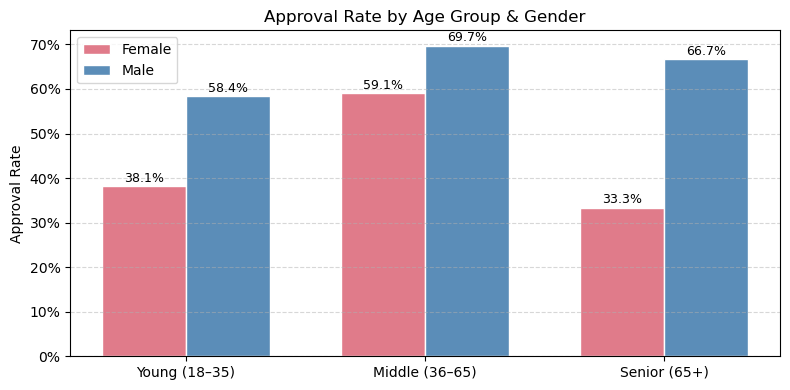


Chi-square test (gender × approval) within each macro age group:
------------------------------------------------------------
  Young (18–35)         χ²=6.861  p=0.0088  → * significant (p < 0.05)
  Middle (36–65)        χ²=3.290  p=0.0697  → not significant
  Senior (65+)          χ²=0.000  p=1.0000  → not significant


In [53]:
# --- Gender × Age Group Interaction (macro-groups) ---

df_int = flat.dropna(subset=["age_group", "gender"]).copy()
df_int = df_int[df_int["gender"].isin(["Male", "Female"])]

# Map to macro-groups
df_int["age_macro"] = pd.cut(
    df_int["age"].astype("float"),
    bins=[17, 35, 65, 100],
    labels=["Young (18–35)", "Middle (36–65)", "Senior (65+)"]
)

# Approval rate by macro-group × gender
pivot = (
    df_int.groupby(["age_macro", "gender"], observed=True)["decision.loan_approved"]
    .agg(approval_rate="mean", n="count")
    .unstack("gender")
)
pivot.columns = [f"{col[1]} ({col[0]})" for col in pivot.columns]

# Single table
rates_table = (
    df_int.groupby(["age_macro", "gender"], observed=True)["decision.loan_approved"]
    .agg(approval_rate="mean", n="count")
    .reset_index()
)
rates_table["approval_rate"] = rates_table["approval_rate"].map("{:.2%}".format)
print(rates_table.to_string(index=False))

# Grouped bar chart
groups   = ["Young (18–35)", "Middle (36–65)", "Senior (65+)"]
x        = range(len(groups))
width    = 0.35

female_rates = [df_int[(df_int["age_macro"] == g) & (df_int["gender"] == "Female")]["decision.loan_approved"].mean() for g in groups]
male_rates   = [df_int[(df_int["age_macro"] == g) & (df_int["gender"] == "Male")]["decision.loan_approved"].mean()   for g in groups]

fig, ax = plt.subplots(figsize=(8, 4))
bars_f = ax.bar([i - width/2 for i in x], female_rates, width, label="Female", color="#E07B8A", edgecolor="white")
bars_m = ax.bar([i + width/2 for i in x], male_rates,   width, label="Male",   color="#5B8DB8", edgecolor="white")

for bar, val in zip(bars_f, female_rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.1%}", ha="center", fontsize=9)
for bar, val in zip(bars_m, male_rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.1%}", ha="center", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(groups)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate by Age Group & Gender")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Chi-square per macro-group
print("\nChi-square test (gender × approval) within each macro age group:")
print("-" * 60)
for grp, subset in [("Young (18–35)", young), ("Middle (36–65)", middle), ("Senior (65+)", senior)]:
    sub = subset[subset["gender"].isin(["Male", "Female"])]
    ct  = pd.crosstab(sub["gender"], sub["decision.loan_approved"])
    if ct.shape == (2, 2):
        chi2, p, _, _ = chi2_contingency(ct)
        sig = "* significant (p < 0.05)" if p < 0.05 else "not significant"
        print(f"  {grp:<20}  χ²={chi2:.3f}  p={p:.4f}  → {sig}")
    else:
        print(f"  {grp:<20}  insufficient data")



**Interpretation:** The approval rates differ across gender within the age groups. In the Young (18–35) group, male applicants have a higher approval rate of 58.43%, compared to female applicants  38.14%. The chi-square test confirms that this difference is statistically significant p = 0.0088 < 0.05, indicating that approval outcomes in this age segment are associated with gender.

In the Middle (36–65) group, male applicants also show a higher approval rate of 69.68%, than female applicants 59.06%. However, the chi-square test yields a p-value of 0.0697, which is above the 0.05 threshold. Therefore, the difference is not statistically significant.

For the Senior (65+) group, male applicants again appear to have a higher approval rate of 66.67% compared to female applicants 33.33%. However, the sample size in this group is extremely small (only 3 observations per gender), and the chi-square test indicates no statistically significant association p = 1.0000.

Overall, the results suggest that gender-related disparities in **approval outcomes are present primarily among younger applicants, while differences in the other age groups are not statistically significant.**

---


## 4. Proxy Analysis
The goal of this analysis is to identify variables, or combinations of variables, that could indirectly reveal information about a protected attribute.

To explore this possibility, we examine whether certain combinations of non-protected variables can be associated with gender. In particular, we analyze the relationship between **Zip Code and loan approval** to assess whether patterns in these variables may help infer the applicant’s gender.

Additionally, a proxy analysis is conducted to evaluate whether the combination of **spending habits and income level**, with the objective of assessing whether these variables together could indirectly encode gender information.

### Zip Code × Loan Approval → Gender 

In [ ]:
# Prepare dataset
df_proxy = flat[["gender", "applicant_info.zip_code", "decision.loan_approved"]].copy()
df_proxy = df_proxy[df_proxy["gender"].isin(["Male", "Female"])].dropna()

# Encode zip code as dummies + approval as 0/1
X = pd.get_dummies(df_proxy["applicant_info.zip_code"].astype(str), prefix="zip")
X["approved"] = df_proxy["decision.loan_approved"].astype(int).values
y = (df_proxy["gender"] == "Female").astype(int).values

# Logistic regression with 5-fold cross-validation
model = LogisticRegression(max_iter=1000, random_state=42)
auc_scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")

print("Proxy Test: Can (zip_code + approval) predict gender?")
print("-" * 50)
print(f"AUC scores (5-fold): {[f'{s:.3f}' for s in auc_scores]}")
print(f"Mean AUC            : {auc_scores.mean():.3f}  (±{auc_scores.std():.3f})")
print()
if auc_scores.mean() > 0.7:
    print("→ STRONG proxy: zip + approval predicts gender well (AUC > 0.7)")
elif auc_scores.mean() > 0.6:
    print("→ MODERATE proxy: some predictive power (AUC > 0.6)")
else:
    print("→ WEAK proxy: zip + approval does not predict gender (AUC ≈ 0.5)")

# Contribution of each variable separately
for label, cols in [("zip only", [c for c in X.columns if c.startswith("zip")]),
                     ("approval only", ["approved"])]:
    auc = cross_val_score(model, X[cols], y, cv=5, scoring="roc_auc").mean()
    print(f"  AUC ({label:<15}): {auc:.3f}")

Proxy Test: Can (zip_code + approval) predict gender?
--------------------------------------------------
AUC scores (5-fold): ['0.816', '0.845', '0.854', '0.817', '0.912']
Mean AUC            : 0.849  (±0.035)

→ STRONG proxy: zip + approval predicts gender well (AUC > 0.7)
  AUC (zip only       ): 0.864
  AUC (approval only  ): 0.576


**How to interpret the AUC**

| AUC value | Interpretation |
|-----------|---------------|
| ≈ 0.5 | No proxy — random guessing |
| 0.6 – 0.7 | Weak proxy |
| > 0.7 | Strong proxy — potential risk of indirect discrimination |

The table above provides a guideline for interpreting the AUC values obtained in the proxy test.  



**Interpretation:** This proxy test evaluates whether the combination of zip code and loan approval can predict the applicant’s gender. The model achieves a **mean AUC of 0.849**, which is well above the threshold of 0.7 commonly used to indicate a strong proxy signal. This result suggests that the information contained in these variables is sufficient to predict gender with relatively high accuracy.

Looking at the variables separately, **zip code alone already shows a strong predictive power (AUC = 0.864)**, while **loan approval alone has a much weaker predictive ability (AUC = 0.576)**. This indicates that the proxy effect is mainly driven by the geographic information contained in the zip code, rather than by the approval decision itself.

Overall, these results suggest that **zip code may encode demographic patterns that are correlated with gender**. 

### Spending Habits × Income → Gender 

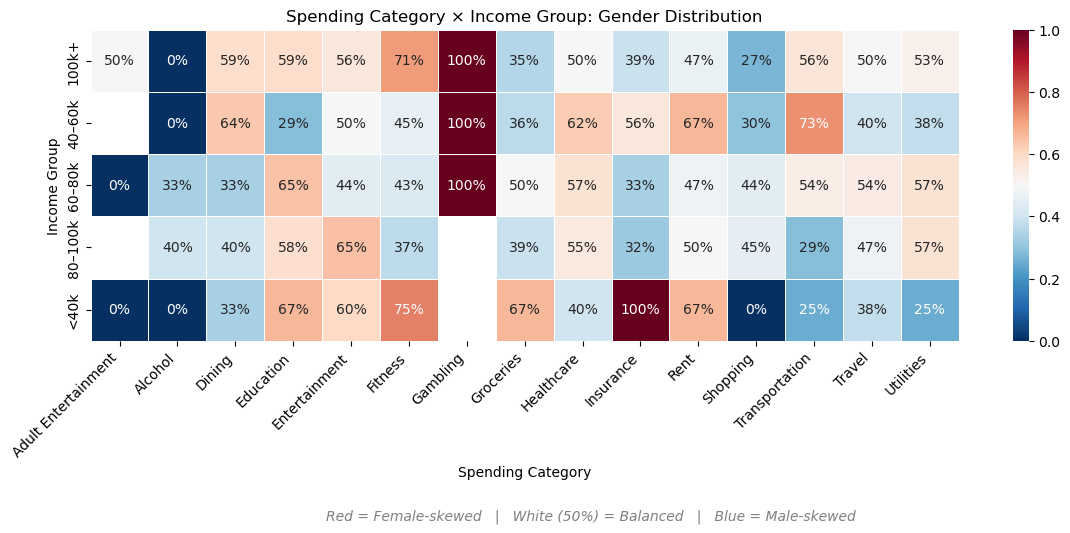

In [65]:
# --- Proxy Analysis: Spending Habits × Income → Gender ---

# Step 1: explode spending_behavior (list of {category, amount})
spend_exp = flat[["_id", "gender", "financials.annual_income", "spending_behavior"]].copy()
spend_exp = spend_exp.dropna(subset=["spending_behavior"])
spend_exp = spend_exp.explode("spending_behavior")
spend_exp = spend_exp[spend_exp["spending_behavior"].apply(lambda x: isinstance(x, dict))]

spend_exp["category"] = spend_exp["spending_behavior"].apply(lambda x: x.get("category", None))
spend_exp["amount"]   = spend_exp["spending_behavior"].apply(lambda x: x.get("amount", 0))

# Step 2: pivot → total spend per person per category
spend_pivot = (
    spend_exp.groupby(["_id", "category"])["amount"]
    .sum()
    .unstack("category")
    .fillna(0)
)
spend_pivot = spend_pivot.join(flat.set_index("_id")[["gender", "financials.annual_income"]])
spend_pivot = spend_pivot[spend_pivot["gender"].isin(["Male", "Female"])]
spend_pivot["financials.annual_income"] = pd.to_numeric(spend_pivot["financials.annual_income"], errors="coerce")

# Step 3: income bins
spend_pivot["income_group"] = pd.cut(
    spend_pivot["financials.annual_income"],
    bins=[0, 40000, 60000, 80000, 100000, 999999],
    labels=["<40k", "40–60k", "60–80k", "80–100k", "100k+"]
)

categories = [c for c in spend_pivot.columns if c not in ["gender", "financials.annual_income", "income_group"]]

# Step 4: heatmap — % Female per (income_group × category)
records = []
for grp, sub in spend_pivot.groupby("income_group", observed=True):
    for cat in categories:
        users_with_cat = sub[sub[cat] > 0]
        if len(users_with_cat) == 0:
            continue
        pct_female = (users_with_cat["gender"] == "Female").mean()
        records.append({"income_group": str(grp), "category": cat, "pct_female": pct_female})

hm = pd.DataFrame(records).pivot(index="income_group", columns="category", values="pct_female")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    hm,
    annot=True,
    fmt=".0%",
    cmap="RdBu_r",
    center=0.5,
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Spending Category × Income Group: Gender Distribution")
ax.set_xlabel("Spending Category")
ax.set_ylabel("Income Group")
plt.xticks(rotation=45, ha="right")

fig.text(
    0.5, -0.05,
    "Red = Female-skewed   |   White (50%) = Balanced   |   Blue = Male-skewed",
    ha="center", fontsize=10, color="gray", style="italic"
)

plt.tight_layout()
plt.show()

C:\Users\madda\AppData\Local\Temp\ipykernel_1440\3635799055.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  colors = sig_mask.applymap(lambda x: "#90EE90" if x else "white")


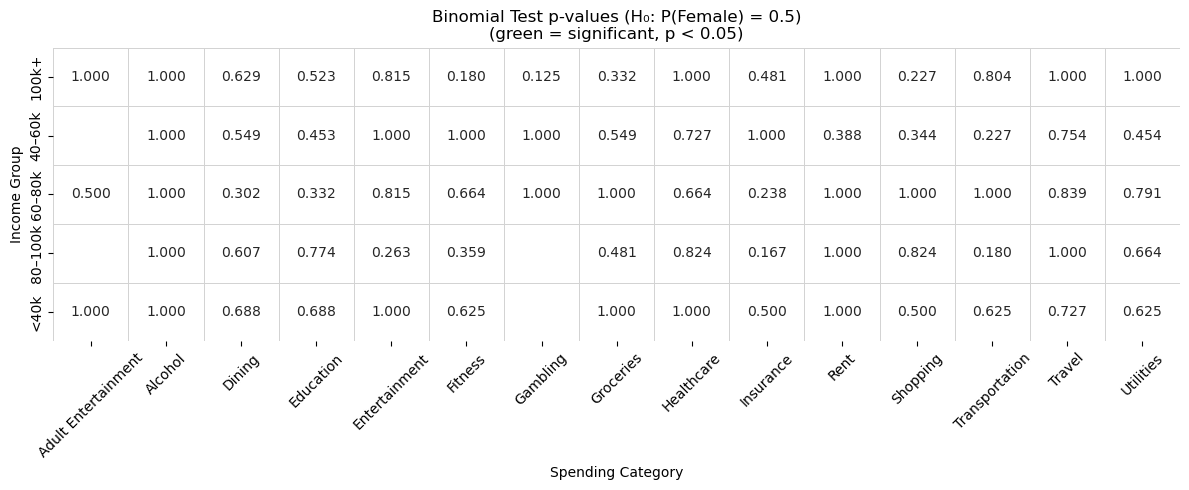

In [73]:
from scipy.stats import binomtest

# Build p-value matrix
records_pval = []
for grp, sub in spend_pivot.groupby("income_group", observed=True):
    for cat in categories:
        users_with_cat = sub[sub[cat] > 0]
        n = len(users_with_cat)
        if n == 0:
            records_pval.append({"income_group": str(grp), "category": cat, "p_value": None})
            continue
        n_female = (users_with_cat["gender"] == "Female").sum()
        p = binomtest(n_female, n, p=0.5, alternative="two-sided").pvalue
        records_pval.append({"income_group": str(grp), "category": cat, "p_value": p})

pval_df = pd.DataFrame(records_pval).pivot(index="income_group", columns="category", values="p_value")

# Plot side by side
fig, ax = plt.subplots(figsize=(12, 5))

# Mask for significant cells
sig_mask = pval_df.astype(float) < 0.05

# White background, green for significant
colors = sig_mask.applymap(lambda x: "#90EE90" if x else "white")

sns.heatmap(pval_df.astype(float), annot=True, fmt=".3f",
            cmap=["white"], vmin=0, vmax=1,
            linewidths=0.5, linecolor="lightgray",
            cbar=False, ax=ax)

# Color significant cells green
for i in range(sig_mask.shape[0]):
    for j in range(sig_mask.shape[1]):
        if sig_mask.iloc[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color="#90EE90", zorder=0))

ax.set_title("Binomial Test p-values (H₀: P(Female) = 0.5)\n(green = significant, p < 0.05)")
ax.set_xlabel("Spending Category")
ax.set_ylabel("Income Group")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()




**Interpretation:** This heatmap explores whether certain spending behaviors are associated with a specific gender and whether this relationship varies across income groups.

Values close to 0% indicate categories where spending is observed only among men, while values close to 100% indicate categories where spending is observed only among women. Values around 50% suggest a more balanced gender distribution. Some categories appear highly skewed toward one gender within specific income groups, suggesting possible associations between spending behavior, income level, and gender. However, these patterns should be interpreted with caution. In several cases where the heatmap shows extreme values (0% or 100%), the number of observations in those income–category combinations is very small, which limits the reliability of these proportions.

To further assess these relationships, an additional grid was computed showing the p-values of the statistical tests for each combination. **These tests do not indicate statistical significance for any of the examined pairs**. Therefore, while the heatmap highlights some descriptive patterns, the current analysis does not provide statistical evidence that these variables are strongly associated with gender or that they could reliably act as proxies for the protected attribute.

---


## 5. Conclusions and Reccomandations

adesso devo scrivere un overall di tutto. e alcuni suggerimenti per evitare questi bias

